# 1. Input và Query Builder


Input: 
- mode = KIS_TEXT
- query gốc = q0
- object contraints từ UI, nếu có
- Ví dụ: q0 = "Một người đàn ông mặc áo vàng dang trả lời phỏng vấn"
- LLM sinh: q1 (paraphrase 1), q2 (paraphrase 2) => text_queries = [q0, q1, q2]
- Các image query có thể gồm: Stable Diffusion image, QUEST external image (nếu bật)

# 2. Các nhánh retrieval song song

**Nhánh A - Visual semantic search**

- Input: q0, q1, q2

- Mỗi câu:
    - PE-Core text encoder
    - vector cùng dimension với visual_features
    - L2 normalize
    - Milvus visual_features
- Output từ Milvus:
    - frame_id
    - video_id
    - shot_id
    - score


**Nhánh B - Stable Diffusion / QUEST image search**

- Input: generated/external image
- Xử lý: 
    - image => PE-Core image encoder
    - L2 normalize
    - Milvus visual_features
- Output:
    - frame_id
    - video_id
    - shot_id
    - score

**Nhánh C - OCR lexical search**

- Input: q0
- Truy vấn: Elasticsearch `ocr_texts.ocr_text_concat`
- Output:
    - frame_id
    - video_id
    - shot_id
    - _score


**Nhánh D - ASR lexical search**

- Input: q0
- Truy vấn: Elasticsearch `asr_transcripts.cleaned_text`
- Output:
    - video_id
    - interval_id
    - start_time
    - end_time
    - cleaned_text
    - _score

**Nhánh E - ASR semantic search**

- Input: q0
- Mỗi query được encode bằng: dangvantuan/vietnamese/embedding
- Sau đó: 768-d vector => L2 normalize => Milvus asr_features
- Output:
    - video_id
    - interval_id
    - start_time_sec
    - end_time_sec
    - score

**Nhánh F - Summary lexical search**

- Input: q0
- Search: Elasticsearch `video_summaries.summary`
- Output:
    - video_id
    - summary
    - _score

**Nhánh G - Summary semantic search**

- Input: q0
- Xử lý: text encoder 768 chiều => L2 normalize => Milvus summary_features
- Output:
    - video_id
    - score

- Hai nhash Summary không prefilter video, không loại bất kỳ video nào. Chúng chỉ tạo `video_score` sau đó bổ trợ cho frame thuộc video đó:
    - frame_score += weight_summary * video_summary_score

# 3. Ánh xạ ASR interval thành keyframe

ASR trả:
- video_id
- start_time
- end_time

Online query SQLite:

In [ ]:
SELECT frame_id, video_id, shot_id, timestamp
FROM metadata
WHERE video_id = ?
ORDER BY timestamp;

Sau đó cần chọn keyframe: timestamp nằm trong [start_time, end_time]. Nếu không có frame nằm đúng interval, ta phải chốt một chính sách: nearest keyframe hoặc temporal neighborhood (Chưa được chốt chính thức)

# 4. Object filter từ UI

Input từ UI người dùng tự chọn:
- label
- count
- position
- confidence
- hard filter hoặc soft boost

Count:

In [ ]:
SELECT frame_id
FROM objects
WHERE label = 'person'
  AND confidence >= 0.4
GROUP BY frame_id
HAVING COUNT(*) = 3;

Position: SQLite hiện chỉ lưu bounding box pixel (x_min, y_min, x_max, y_max). Nhưng SQLite metadata không lưu image_width, image_height. Vì vậy để UI dùng vùng chuẩn hóa [0, 1], Backend phải:

1. đọc kích thước keyframe image khi filter

hoặc

2. bổ sung width/height vào metadata

hoặc

3. Offline lưu bbox đã normalize

Đây là một điểm phải chốt trước khi code position filter. Paper SOICT 2023 cũng dùng object class, count và bounding box để cho người dùng chọn vị trí trên UI rồi lọc kết quả

# 5. Score Normalization

Các score không cùng thang đo:
- Milvus IP score
- Elasticsearch BM25 score
- Summary video score
- Object boost

Do đó phải normalize riêng từng branch:
- visual
- OCR
- ASR lexical
- ASR semantic
- summary lexical
- summary semantic
- SD
- QUEST

Phương pháp Normalization và trọng số cụ thể chưa được chốt bằng schema

# 6. Fusion

Mỗi frame có thể nhận điểm từ nhiều nguồn:
- visual score
- OCR score
- ASR lexical score
- ASR semantic score
- summary lexical video boost
- summary semantic video boost
- object boost

Dạng logic:

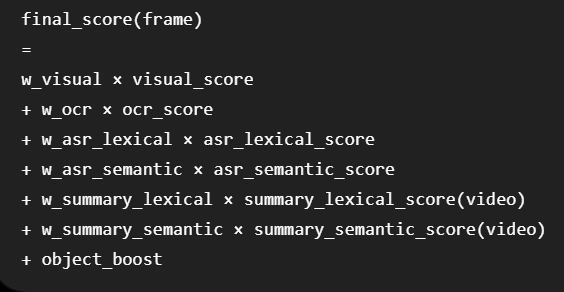

# 7. Dedup và group near frames

- Input: các frame đã có final_score
- Xử lý: 
    - group theo video_id + shot_id
    - giữ frame có final_score cao nhất
    - các frame khác trong shot thành near_frames
- Output cuối KIS: VideoId, FrameId
- Thông tin nội bộ có thể giữ:
    - timestamp
    - shot_id
    - final_score
    - branch_scores
    - near_frames